In [ ]:
# @title Voxel XYZ-to-RGB Sorter
import json
import numpy as np
from PIL import Image
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from google.colab import files
import io

def run_sorter():
    # --- 1. UPLOAD FILES ---
    print(" UPLOAD YOUR VOXEL JSON FILE ")
    uploaded_json = files.upload()
    json_filename = list(uploaded_json.keys())[0]

    print("\n UPLOAD YOUR TARGET IMAGE ")
    uploaded_img = files.upload()
    img_filename = list(uploaded_img.keys())[0]

    # --- 2. PARSE VOXEL DATA ---
    print(f"\nProcessing {json_filename}...")
    with open(json_filename, 'r') as f:
        data = json.load(f)

    # robust parser for Drububu or generic JSON
    coords = []

    # Check if 'voxels' key exists (Drububu format)
    if 'voxels' in data:
        source_list = data['voxels']
    else:
        # Assume the file itself is a list of points
        source_list = data

    # Extract X, Y, Z
    for v in source_list:
        if isinstance(v, dict):
             # Try standard keys
             x = v.get('x', v.get('X', 0))
             y = v.get('y', v.get('Y', 0))
             z = v.get('z', v.get('Z', 0))
             coords.append([x, y, z])
        elif isinstance(v, list) and len(v) >= 3:
             coords.append(v[:3])

    coords = np.array(coords)
    print(f"   Found {len(coords)} voxels in your model.")

    if len(coords) == 0:
        print(" Error: Could not find voxel coordinates in JSON.")
        return

    # --- 3. NORMALIZE (XYZ -> RGB) ---
    print("Generating color palette from 3D Geometry...")
    min_c = coords.min(axis=0)
    max_c = coords.max(axis=0)

    # Avoid division by zero if flat
    range_c = max_c - min_c
    range_c[range_c == 0] = 1

    # The Magic: Convert Position to Color
    palette = ((coords - min_c) / range_c * 255).astype(np.uint8)

    # --- 4. MATCHING ---
    print("Mapping image pixels to voxel geometry...")
    img = Image.open(io.BytesIO(uploaded_img[img_filename])).convert('RGB')
    img_array = np.array(img)
    h, w, _ = img_array.shape
    target_pixels = img_array.reshape(-1, 3)

    # KDTree for fast nearest-neighbor search
    tree = KDTree(palette)
    _, indices = tree.query(target_pixels)

    # --- 5. RECONSTRUCT ---
    new_pixels = palette[indices]
    final_img_array = new_pixels.reshape(h, w, 3)

    # Save and Show
    result_filename = "output_voxel_art.png"
    result_img = Image.fromarray(final_img_array)
    result_img.save(result_filename)

    print(f"\n DONE! Saved as {result_filename}")

    # Display in Notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(final_img_array)
    plt.axis('off')
    plt.title("Result: Image Mapped to Voxel Geometry")
    plt.show()

    # Trigger Download
    files.download(result_filename)

if __name__ == "__main__":
    run_sorter()

 UPLOAD YOUR VOXEL JSON FILE 


Saving heart.json to heart.json

 UPLOAD YOUR TARGET IMAGE 


Saving IMG_2317.jpg to IMG_2317.jpg

Processing heart.json...
   Found 3957 voxels in your model.
Generating color palette from 3D Geometry...


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U2'), dtype('<U2')) -> None

 UPLOAD YOUR VOXEL JSON FILE 


Saving heart.json to heart.json

 UPLOAD YOUR TARGET IMAGE 


Saving IMG_2317.jpg to IMG_2317.jpg
Parsing JSON...
   Found 3957 valid voxels.
Processing Image...
   Image Pixels: 1624260 | Voxel Colors: 3957
Sorting pixels by brightness (Luma Sort)...

 DONE! Saved as output_luma_sort.png


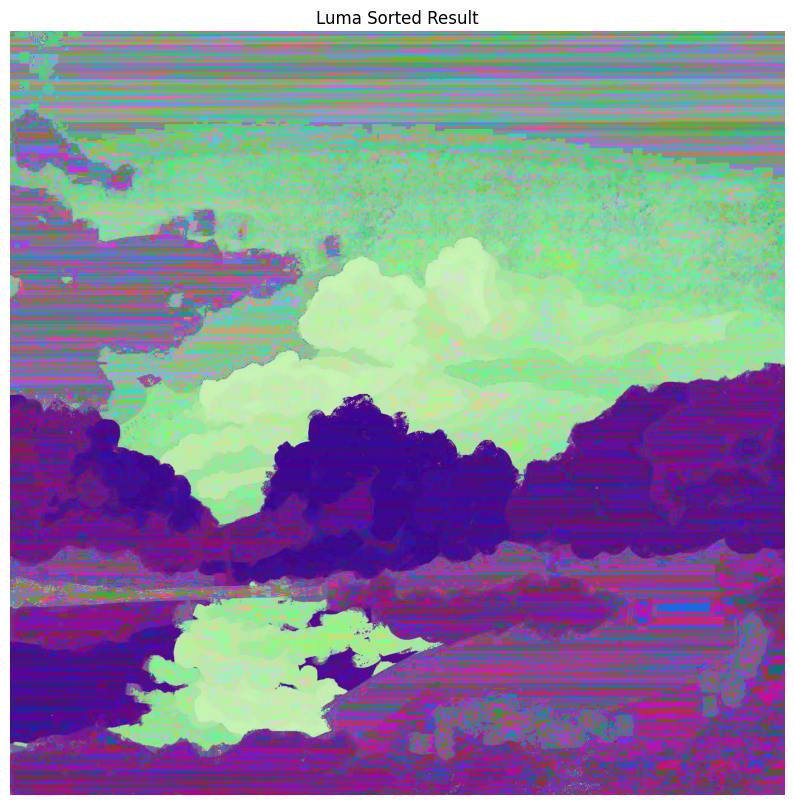

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title Voxel "Luma Sort" (Fixed for String Data)
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io

def calculate_brightness(rgb_array):
    # Standard formula for converting RGB to Grayscale (Luminance)
    # 0.299*R + 0.587*G + 0.114*B
    return np.dot(rgb_array[...,:3], [0.299, 0.587, 0.114])

def run_luma_sort():
    # --- 1. UPLOAD FILES ---
    print(" UPLOAD YOUR VOXEL JSON FILE ")
    uploaded_json = files.upload()
    json_filename = list(uploaded_json.keys())[0]

    print("\n UPLOAD YOUR TARGET IMAGE ")
    uploaded_img = files.upload()
    img_filename = list(uploaded_img.keys())[0]

    # --- 2. PREPARE VOXEL PALETTE ---
    print("Parsing JSON...")
    with open(json_filename, 'r') as f:
        data = json.load(f)

    # Parse JSON (FIXED: Force conversion to float)
    coords = []

    # Handle Drububu 'voxels' key or raw list
    source_list = data.get('voxels', data)

    for v in source_list:
        try:
            if isinstance(v, dict):
                # Force float() on the values to handle strings like "10"
                x = float(v.get('x', v.get('X', 0)))
                y = float(v.get('y', v.get('Y', 0)))
                z = float(v.get('z', v.get('Z', 0)))
                coords.append([x, y, z])
            elif isinstance(v, list) and len(v) >= 3:
                # Force float() on list items
                coords.append([float(i) for i in v[:3]])
        except ValueError:
            continue # Skip bad data points

    coords = np.array(coords)
    print(f"   Found {len(coords)} valid voxels.")

    if len(coords) == 0:
        print(" Error: No valid numeric coordinates found. Check your JSON format.")
        return

    # Normalize XYZ to RGB
    min_c = coords.min(axis=0)
    max_c = coords.max(axis=0)
    range_c = max_c - min_c

    # Avoid division by zero
    range_c[range_c == 0] = 1

    voxel_colors = ((coords - min_c) / range_c * 255).astype(np.uint8)

    # --- 3. PREPARE IMAGE ---
    print("Processing Image...")
    img = Image.open(io.BytesIO(uploaded_img[img_filename])).convert('RGB')
    img_array = np.array(img)
    h, w, _ = img_array.shape

    # Flatten image to a list of pixels
    flat_img = img_array.reshape(-1, 3)
    num_pixels = len(flat_img)
    num_voxels = len(voxel_colors)

    print(f"   Image Pixels: {num_pixels} | Voxel Colors: {num_voxels}")

    # --- 4. RESAMPLING ---
    if num_voxels < num_pixels:
        repeat_factor = int(np.ceil(num_pixels / num_voxels))
        voxel_colors = np.tile(voxel_colors, (repeat_factor, 1))
        voxel_colors = voxel_colors[:num_pixels]
    elif num_voxels > num_pixels:
        # Randomly sample to fit size
        indices = np.random.choice(num_voxels, num_pixels, replace=False)
        voxel_colors = voxel_colors[indices]

    # --- 5. THE SORTING LOGIC ---
    print("Sorting pixels by brightness (Luma Sort)...")

    # A. Calculate Brightness
    img_lum = calculate_brightness(flat_img)
    vox_lum = calculate_brightness(voxel_colors)

    # B. Get sort order
    img_sort_order = np.argsort(img_lum)    # Indices to sort Image Dark -> Light
    vox_sort_order = np.argsort(vox_lum)    # Indices to sort Voxels Dark -> Light

    # C. Map Ranks
    # We want the Nth darkest image pixel to take the color of the Nth darkest voxel
    # img_ranks maps the original pixel index to its sorted rank
    img_ranks = np.argsort(img_sort_order)

    # Sort the voxels by brightness
    sorted_voxels = voxel_colors[vox_sort_order]

    # Apply them to the original image positions
    final_pixels = sorted_voxels[img_ranks]

    # --- 6. SAVE ---
    final_img_array = final_pixels.reshape(h, w, 3)

    result_filename = "output_luma_sort.png"
    Image.fromarray(final_img_array).save(result_filename)

    print(f"\n DONE! Saved as {result_filename}")

    plt.figure(figsize=(10, 10))
    plt.imshow(final_img_array)
    plt.axis('off')
    plt.title("Luma Sorted Result")
    plt.show()

    files.download(result_filename)

if __name__ == "__main__":
    run_luma_sort()

In [ ]:
# @title Voxel "Un-Normalizer" (Image -> 3D Point Cloud)
import json
import numpy as np
from PIL import Image
from google.colab import files
import io

def run_unnormalize():
    # --- 1. UPLOAD FILES ---
    # We need the original JSON to know the "Scale" (Bounds) of the model
    print(" UPLOAD THE ORIGINAL VOXEL JSON (For Scale) ")
    uploaded_json = files.upload()
    json_filename = list(uploaded_json.keys())[0]

    # We need the Image you want to turn back into 3D
    print("\n UPLOAD THE 'SORTED' IMAGE (The Result) ")
    uploaded_img = files.upload()
    img_filename = list(uploaded_img.keys())[0]

    # --- 2. RE-CALCULATE BOUNDS ---
    # We need to remember how big the original model was to un-squish it correctly
    with open(json_filename, 'r') as f:
        data = json.load(f)

    # Parse coords again just to get min/max
    coords = []
    source_list = data.get('voxels', data)
    for v in source_list:
        if isinstance(v, dict):
             coords.append([v.get('x',0), v.get('y',0), v.get('z',0)])
        elif isinstance(v, list) and len(v) >= 3:
             coords.append(v[:3])
    coords = np.array(coords)

    if len(coords) == 0:
        print("Error reading JSON.")
        return

    min_c = coords.min(axis=0)
    max_c = coords.max(axis=0)
    range_c = max_c - min_c
    range_c[range_c == 0] = 1

    print(f"Original Bounds: Min {min_c} | Max {max_c}")

    # --- 3. PROCESS THE IMAGE ---
    print("Reading Image Colors...")
    img = Image.open(io.BytesIO(uploaded_img[img_filename])).convert('RGB')
    img_data = np.array(img)

    # Flatten pixels
    pixels = img_data.reshape(-1, 3)

    # --- 4. THE MATH (REVERSE NORMALIZATION) ---
    # Formula: Position = (Color / 255) * Range + Min
    print("Un-normalizing (RGB -> XYZ)...")

    # normalizing_factor is 255 for 8-bit images
    new_coords = (pixels / 255.0) * range_c + min_c

    # --- 5. WRITE TO .PLY FILE ---
    # PLY is a standard format for point clouds
    ply_filename = "reconstructed_heart.ply"

    print(f"Writing {len(new_coords)} points to {ply_filename}...")

    with open(ply_filename, 'w') as f:
        # Write Header
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(new_coords)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")

        # Write Points
        # We save the coordinate (X,Y,Z) AND the color (R,G,B)
        # In this specific technique, the Color matches the Position exactly.
        for i in range(len(new_coords)):
            x, y, z = new_coords[i]
            r, g, b = pixels[i]
            f.write(f"{x:.3f} {y:.3f} {z:.3f} {r} {g} {b}\n")

    print(f" DONE! Download {ply_filename} and open it in Blender or MeshLab.")
    files.download(ply_filename)

if __name__ == "__main__":
    run_unnormalize()

 UPLOAD THE ORIGINAL VOXEL JSON (For Scale) 


KeyboardInterrupt: 

In [ ]:
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io

def calculate_brightness(rgb_array):
    # 0.299*R + 0.587*G + 0.114*B
    return np.dot(rgb_array[...,:3], [0.299, 0.587, 0.114])

def run_luma_sort():
    uploaded_json = files.upload()
    json_filename = list(uploaded_json.keys())[0]

    uploaded_img = files.upload()
    img_filename = list(uploaded_img.keys())[0]

    print("Parsing JSON...")
    with open(json_filename, 'r') as f:
        data = json.load(f)

    coords = []

    source_list = data.get('voxels', data)

    for v in source_list:
        try:
            if isinstance(v, dict):
                x = float(v.get('x', v.get('X', 0)))
                y = float(v.get('y', v.get('Y', 0)))
                z = float(v.get('z', v.get('Z', 0)))
                coords.append([x, y, z])
            elif isinstance(v, list) and len(v) >= 3:
                coords.append([float(i) for i in v[:3]])
        except ValueError:
            continue

    coords = np.array(coords)
    print(f"   Found {len(coords)} valid voxels.")

    if len(coords) == 0:
        print(" Error: No valid numeric coordinates found. Check your JSON format.")
        return

    min_c = coords.min(axis=0)
    max_c = coords.max(axis=0)
    range_c = max_c - min_c

    range_c[range_c == 0] = 1

    voxel_colors = ((coords - min_c) / range_c * 255).astype(np.uint8)


    img = Image.open(io.BytesIO(uploaded_img[img_filename])).convert('RGB')
    img_array = np.array(img)
    h, w, _ = img_array.shape

    flat_img = img_array.reshape(-1, 3)
    num_pixels = len(flat_img)
    num_voxels = len(voxel_colors)

    print(f"   Image Pixels: {num_pixels} | Voxel Colors: {num_voxels}")

    # --- 4. RESAMPLING ---
    if num_voxels < num_pixels:
        repeat_factor = int(np.ceil(num_pixels / num_voxels))
        voxel_colors = np.tile(voxel_colors, (repeat_factor, 1))
        voxel_colors = voxel_colors[:num_pixels]
    elif num_voxels > num_pixels:
        # Randomly sample to fit size
        indices = np.random.choice(num_voxels, num_pixels, replace=False)
        voxel_colors = voxel_colors[indices]

    # --- 5. THE SORTING LOGIC ---
    print("Sorting pixels by brightness (Luma Sort)...")

    # A. Calculate Brightness
    img_lum = calculate_brightness(flat_img)
    vox_lum = calculate_brightness(voxel_colors)

    # B. Get sort order
    img_sort_order = np.argsort(img_lum)    # Indices to sort Image Dark -> Light
    vox_sort_order = np.argsort(vox_lum)    # Indices to sort Voxels Dark -> Light

    # C. Map Ranks
    # We want the Nth darkest image pixel to take the color of the Nth darkest voxel
    # img_ranks maps the original pixel index to its sorted rank
    img_ranks = np.argsort(img_sort_order)

    # Sort the voxels by brightness
    sorted_voxels = voxel_colors[vox_sort_order]

    # Apply them to the original image positions
    final_pixels = sorted_voxels[img_ranks]

    # --- 6. SAVE ---
    final_img_array = final_pixels.reshape(h, w, 3)

    result_filename = "output_luma_sort.png"
    Image.fromarray(final_img_array).save(result_filename)

    print(f"\n DONE! Saved as {result_filename}")

    plt.figure(figsize=(10, 10))
    plt.imshow(final_img_array)
    plt.axis('off')
    plt.title("Luma Sorted Result")
    plt.show()

    files.download(result_filename)

if __name__ == "__main__":
    run_luma_sort()